
# Check models are detectable with gammapy

In [1]:
import numpy as np
from pathlib import Path

from astropy.table import Table
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord
from astropy.time import Time
from regions import CircleSkyRegion, PointSkyRegion
import matplotlib.pyplot as plt
from gammapy.data import FixedPointingInfo, Observation, observatory_locations
from gammapy.datasets import MapDataset, MapDatasetEventSampler
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker
from gammapy.maps import MapAxis, RegionNDMap, WcsGeom, TimeMapAxis
from gammapy.modeling.models import (
    ConstantSpectralModel,
    FoVBackgroundModel,
    LightCurveTemplateTemporalModel,
    PointSpatialModel,
    PowerLawSpectralModel,
    SkyModel,
    Models
)


import pandas as pd

from sensipy import ctaoirf

./.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import gammapy
gammapy.__version__

'2.0.1'

In [3]:
meta = pd.read_csv("./metadata/CTAO-SDC-metadata.csv")

import a model

In [4]:
meta[meta.model_id == 301]

,sdc_event_id,superevent_id,model_id,model_filepath,gcn_filepath,timestamp_utc,distance_mpc,z,alert_ifos,alert_area90,alert_distance90,tilepy_n_observations,tilepy_prob_covered,tilepy_pointings,tilepy_first_ra,tilepy_first_dec,tilepy_first_latency,tilepy_first_utc
692,694,GW290206a,301,gammapy_models/GW290206a_catO5_301_gammapy.fits,GCNs/GW290206a_GCN.json,2029-02-06 13:24:04.390817,843.0,0.17,"[""H1"", ""K1"", ""L1""]",999.143014,824.243107,5,0.0652,"[{""ra"": 267.0117, ""dec"": -7.7827, ""latency"": 6...",267.0117,-7.7827,68969.0,2029-02-07 08:33:33
786,790,GW290328a,301,gammapy_models/GW290328a_catO5_301_gammapy.fits,GCNs/GW290328a_GCN.json,2029-03-28 01:28:54.922402,843.0,0.17,"[""H1"", ""K1"", ""L1""]",999.143014,824.243107,45,0.8013,"[{""ra"": 266.8359, ""dec"": -8.2347, ""latency"": 1...",266.8359,-8.2347,13830.0,2029-03-28 05:19:24


In [4]:
filename = "../gammapy_models/GW290206a_catO5_301_gammapy.fits"

In [6]:
temporal_model = LightCurveTemplateTemporalModel.read(filename, format="map")
# temporal_model.method = "linear"  # default
# temporal_model.values_scale = "log"  # default

'log'

./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 2 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1001 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1000 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1000 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/pyth

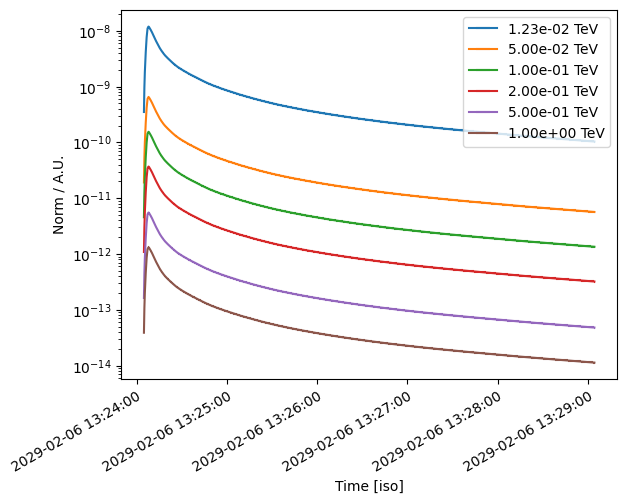

In [11]:
time_range = temporal_model.reference_time + [0.3, 300] * u.s

temporal_model.plot(time_range=time_range, energy=[0.0123, 0.05, 0.1, 0.2, 0.5, 1] * u.TeV, n_points=1000)
plt.semilogy()
plt.legend()

## Set simulation inputs

In [12]:
pointing_plan = Table.read("./pointing_plan-c.fits", format="fits")
pointing_plan["ObsID"] = pointing_plan["ObsID"].astype(int)

In [13]:
line = pointing_plan[pointing_plan["ObsID"] == 5000003425]
line

name,target_RA,target_Dec,ID,Type,Array,Mode,wobble_position,pointing_RA,pointing_DEC,Zen. range,time_start,time_stop,exposure,IRF,ObsID
,deg,deg,,,,,,deg,deg,,,,s,,
bytes34,float64,float64,float64,bytes1,bytes5,bytes6,float64,float64,float64,bytes38,bytes23,bytes23,float64,bytes134,int64
Transients-GW - Event #301,274.219,1.492,21.0,t,South,custom,0.0,274.219,1.492,29.107268623384996-29.160532165117083,2028-06-24T05:40:24.000,2028-06-24T05:40:54.000,30.00000000000469,/home/jovyan/MAKE_SDC/input/caldb/CTA-Performance-prod5-v0.1-South-20deg/Prod5-South-20deg-AverageAz-14MSTs37SSTs.18000s-v0.1.fits.gz,5000003425


In [14]:
RA = line.to_pandas().iloc[0].pointing_RA
dec = line.to_pandas().iloc[0].pointing_DEC

print(f"Pointing coordinates: {RA}, {dec}")

# pointing properties
pointing_coordinates = SkyCoord(ra=RA, dec=dec, unit="deg", frame="icrs")

# exposure time
livetime = 30.00000000000469 * u.s
#livetime = 60 * u.s

house = ctaoirf.IRFHouse(base_directory="./notebooks/IRFs")
# house.get_irf(site="south", configuration="alpha", zenith=20, duration=1800, azimuth="average", version="prod5-v0.1")
irf_path = "./notebooks/IRFs/CTAO/prod5-v0.1/fits/Prod5-South-20deg-AverageAz-14MSTs37SSTs.1800s-v0.1.fits.gz"

Pointing coordinates: 274.219, 1.492


In [15]:
location = observatory_locations["cta_south"]


In [16]:
# energy range (true and reco) for the simulation
e_min, e_max = 0.012589254, 199.52623
energy_axis = MapAxis.from_energy_bounds(f"{e_min} TeV", f"{e_max} TeV", nbin=10, per_decade=True)
energy_axis_true = MapAxis.from_energy_bounds(
    "0.001 TeV", "250 TeV", nbin=10, per_decade=True, name="energy_true"
)

In [17]:
# geomtry properties of the simulation
width = 2 # in deg
binsz = 0.01 # in deg

# reference time of the 1SDC
t_ref = Time("2028-01-01T00:00:00", format="isot", scale="utc")

## Make the sky model

In [15]:
# define the sky model
spatial_model = PointSpatialModel.from_position(pointing_coordinates)
spectral_model = ConstantSpectralModel(const="1 cm-2 s-1 GeV-1")

model = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    temporal_model=temporal_model,
    name="GW",
)

#cosmic bkg from the IRF
bkg_model = FoVBackgroundModel(dataset_name="my-dataset")

#make the full model
models = Models([model, bkg_model])

In [16]:
print(models)

Models

Component 0: SkyModel

  Name                      : GW
  Datasets names            : None
  Spectral model type       : ConstantSpectralModel
  Spatial  model type       : PointSpatialModel
  Temporal model type       : LightCurveTemplateTemporalModel
  Parameters:
    const                         :      1.000   +/-    0.00 1 / (GeV s cm2)
    lon_0                         :    274.219   +/-    0.00 deg         
    lat_0                         :      1.492   +/-    0.00 deg         
    t_ref                 (frozen):  62173.558       d           

Component 1: FoVBackgroundModel

  Name                      : my-dataset-bkg
  Datasets names            : ['my-dataset']
  Spectral model type       : PowerLawNormSpectralModel
  Parameters:
    tilt                  (frozen):      0.000                   
    norm                          :      1.000   +/-    0.00             
    reference             (frozen):      1.000       TeV         




In [17]:
pointing = FixedPointingInfo(
    fixed_icrs=pointing_coordinates.icrs,
)

irfs = load_irf_dict_from_file(irf_path)

In [18]:
irfs

{'aeff': <gammapy.irf.effective_area.EffectiveAreaTable2D at 0x11ff48200>,
 'psf': <gammapy.irf.psf.parametric.EnergyDependentMultiGaussPSF at 0x11d4cc8c0>,
 'edisp': <gammapy.irf.edisp.core.EnergyDispersion2D at 0x11ff1b050>,
 'bkg': <gammapy.irf.background.Background3D at 0x11fec48f0>}

In [21]:
temporal_model.reference_time

<Time object: scale='utc' format='mjd' value=62173.55838415297>

define the observation object

In [24]:
t_ref

<Time object: scale='utc' format='isot' value=2028-01-01T00:00:00.000>

In [27]:
# tstart = Time("2028-06-24T05:40:24.000", format="isot", scale="utc")
tstart = temporal_model.reference_time

observation = Observation.create(
    obs_id="0001",
    pointing=pointing,
    livetime=livetime,
    irfs=irfs,
    location=location,
    reference_time=t_ref,
    tstart=(tstart.utc.mjd-t_ref.utc.mjd) * u.d,
)
print(observation)

Observation

	obs id            : 0001 
 	tstart            : 62173.56
	tstop             : 62173.56
	duration          : 30.00 s
	pointing (icrs)   : 274.2 deg, 1.5 deg

	deadtime fraction : 0.0%



./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [28]:
observation.gti

define simulation geometry

In [29]:
migra_axis = MapAxis.from_bounds(0.5, 2, nbin=150, node_type="edges", name="migra")

geom = WcsGeom.create(
    skydir=pointing.fixed_icrs,
    width=(width, width),
    binsz=binsz,
    frame="icrs",
    axes=[energy_axis],
)

create map dataset

In [36]:
empty = MapDataset.create(
    geom,
    energy_axis_true=energy_axis_true,
    migra_axis=migra_axis,
    name="my-dataset",
)
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
dataset = maker.run(empty, observation)

./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/si

In [38]:
# Attach models to the dataset (required in gammapy >= 2.0)
dataset.models = models
print(dataset.models)

DatasetModels

Component 0: SkyModel

  Name                      : GW
  Datasets names            : None
  Spectral model type       : ConstantSpectralModel
  Spatial  model type       : PointSpatialModel
  Temporal model type       : LightCurveTemplateTemporalModel
  Parameters:
    const                         :      1.000   +/-    0.00 1 / (GeV s cm2)
    lon_0                         :    274.219   +/-    0.00 deg         
    lat_0                         :      1.492   +/-    0.00 deg         
    t_ref                 (frozen):  62173.558       d           

Component 1: FoVBackgroundModel

  Name                      : my-dataset-bkg
  Datasets names            : ['my-dataset']
  Spectral model type       : PowerLawNormSpectralModel
  Parameters:
    tilt                  (frozen):      0.000                   
    norm                          :      1.000   +/-    0.00             
    reference             (frozen):      1.000       TeV         




simulate events

In [39]:
sampler = MapDatasetEventSampler(random_state=0, oversample_energy_factor=10)
events = sampler.run(dataset, observation)

print(f"Source events: {(events.table['MC_ID'] == 1).sum()}")
print(f"Background events: {(events.table['MC_ID'] == 0).sum()}")

./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 60 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 59 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 59 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12

Source events: 1327
Background events: 973


./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [40]:
events.table

TIME,ENERGY_TRUE,RA_TRUE,DEC_TRUE,MC_ID,RA,DEC,ENERGY,EVENT_ID,DETX,DETY
,TeV,deg,deg,,deg,deg,TeV,,deg,deg
Time,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64
62173.558384238546,0.39608922208163155,273.70646417904743,1.031425016982467,0,273.70646417904743,1.031425016982467,0.39608922208163155,1573,-0.5124693274223144,-0.4605153023479785
62173.55838424871,0.05361274293619636,273.6343859212104,2.1498357258766236,0,273.6343859212104,2.1498357258766236,0.05361274293619636,2087,-0.5842410979722447,0.6579133330902961
62173.558384303695,0.8906767440556099,273.76455994816445,0.6186512211555617,0,273.76455994816445,0.6186512211555617,0.8906767440556099,1745,-0.4544663513777809,-0.8733018520877802
62173.5583845065,0.08236902964068248,274.5602698577338,1.5722253236525434,0,274.5602698577338,1.5722253236525434,0.08236902964068248,1900,0.3411417139686036,0.08025177671489125
62173.55838460594,0.051682896938138746,273.82075956613676,2.375977855940632,0,273.82075956613676,2.375977855940632,0.051682896938138746,1969,-0.3979454265666476,0.8840138649856791
62173.55838510833,0.057736424163580685,275.2015979992696,0.9755302480596575,0,275.2015979992696,0.9755302480596575,0.057736424163580685,1534,0.9824954506671819,-0.5162504006110681
62173.558385164084,0.0949022795844595,274.63652656031167,1.035595370167238,0,274.63652656031167,1.035595370167238,0.0949022795844595,1342,0.4174716030871921,-0.4563650245054511
62173.558385473836,0.21438527010568842,273.5300414745707,2.311143313140047,0,273.5300414745707,2.311143313140047,0.21438527010568842,1407,-0.6884684608117452,0.8192510877311137


./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 2300 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


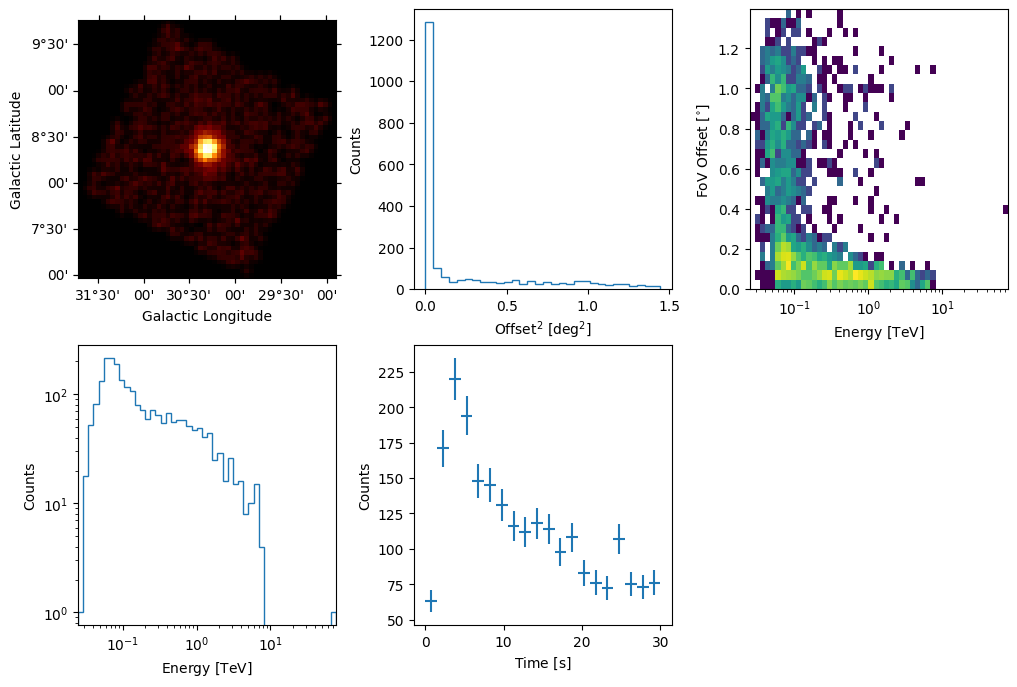

In [41]:
events.peek()

## Try with redshift

In [20]:
import os


# set environment variable
os.environ["GAMMAPY_DATA"] = "./notebooks/gammapy-data"


In [70]:
# define the sky model
from gammapy.modeling.models import EBLAbsorptionNormSpectralModel

redshift = 1.0


# Apply EBL absorption directly to the temporal model's flux data
# The temporal model contains a RegionNDMap with flux as a function of energy and time
if redshift is not None and redshift > 0:
    # Create EBL absorption model
    ebl_absorption = EBLAbsorptionNormSpectralModel.read_builtin(
        "franceschini",  # or "dominguez", "finke", "franceschini17", "saldana-lopez21"
        redshift=redshift
    )
    
    # Get the energy axis from the temporal model's map
    energy_axis_temporal = temporal_model.map.geom.axes["energy"]
    energies = energy_axis_temporal.center
    
    # Evaluate EBL absorption at each energy
    ebl_factors = ebl_absorption.evaluate(energy=energies, redshift=redshift, alpha_norm=1)
    
    # Ensure ebl_factors is a plain numpy array (not a Quantity)
    if hasattr(ebl_factors, 'value'):
        ebl_factors = ebl_factors.value
    ebl_factors = np.asarray(ebl_factors)
    
    # Apply EBL absorption to the flux data
    map_data = temporal_model.map.data.copy()
    
    # Get the data shape
    data_shape = map_data.shape
    
    # Find which dimension in the data array corresponds to energy
    # by matching the size with the number of energy bins
    energy_size = len(ebl_factors)
    energy_dim_in_data = None
    for i, size in enumerate(data_shape):
        if size == energy_size:
            energy_dim_in_data = i
            break
    
    if energy_dim_in_data is None:
        raise ValueError(f"Could not find energy dimension in data shape {data_shape} matching energy size {energy_size}")
    
    # Create a shape tuple for broadcasting: all 1s except at energy dimension
    broadcast_shape = [1] * len(data_shape)
    broadcast_shape[energy_dim_in_data] = energy_size
    
    # Reshape ebl_factors to match the broadcast shape
    ebl_factors_expanded = ebl_factors.reshape(tuple(broadcast_shape))
    
    # Multiply flux by EBL absorption factors
    result = map_data * ebl_factors_expanded
    
    # Ensure result is a plain numpy array (not a Quantity)
    if hasattr(result, 'value'):
        result = result.value
    temporal_model.map.data = np.asarray(result)

# Now create the sky model with ConstantSpectralModel (required for event sampler)
spatial_model = PointSpatialModel.from_position(pointing_coordinates)
spectral_model = ConstantSpectralModel(const="1 cm-2 s-1 GeV-1")

model = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    temporal_model=temporal_model,
    name="GW",
)

#cosmic bkg from the IRF
bkg_model = FoVBackgroundModel(dataset_name="my-dataset")

#make the full model
models = Models([model, bkg_model])

In [71]:
print(models)

Models

Component 0: SkyModel

  Name                      : GW
  Datasets names            : None
  Spectral model type       : ConstantSpectralModel
  Spatial  model type       : PointSpatialModel
  Temporal model type       : LightCurveTemplateTemporalModel
  Parameters:
    const                         :      1.000   +/-    0.00 1 / (GeV s cm2)
    lon_0                         :    274.219   +/-    0.00 deg         
    lat_0                         :      1.492   +/-    0.00 deg         
    t_ref                 (frozen):  62173.558       d           

Component 1: FoVBackgroundModel

  Name                      : my-dataset-bkg
  Datasets names            : ['my-dataset']
  Spectral model type       : PowerLawNormSpectralModel
  Parameters:
    tilt                  (frozen):      0.000                   
    norm                          :      1.000   +/-    0.00             
    reference             (frozen):      1.000       TeV         




In [72]:
pointing = FixedPointingInfo(
    fixed_icrs=pointing_coordinates.icrs,
)

irfs = load_irf_dict_from_file(irf_path)

In [73]:
irfs

{'aeff': <gammapy.irf.effective_area.EffectiveAreaTable2D at 0x122b89520>,
 'psf': <gammapy.irf.psf.parametric.EnergyDependentMultiGaussPSF at 0x12316f9e0>,
 'edisp': <gammapy.irf.edisp.core.EnergyDispersion2D at 0x1230cc5c0>,
 'bkg': <gammapy.irf.background.Background3D at 0x122c70b90>}

In [74]:
temporal_model.reference_time

<Time object: scale='utc' format='mjd' value=62173.55838415297>

define the observation object

In [75]:
t_ref

<Time object: scale='utc' format='isot' value=2028-01-01T00:00:00.000>

In [76]:
# tstart = Time("2028-06-24T05:40:24.000", format="isot", scale="utc")
tstart = temporal_model.reference_time

observation = Observation.create(
    obs_id="0001",
    pointing=pointing,
    livetime=livetime,
    irfs=irfs,
    location=location,
    reference_time=t_ref,
    tstart=(tstart.utc.mjd-t_ref.utc.mjd) * u.d,
)
print(observation)

Observation

	obs id            : 0001 
 	tstart            : 62173.56
	tstop             : 62173.56
	duration          : 30.00 s
	pointing (icrs)   : 274.2 deg, 1.5 deg

	deadtime fraction : 0.0%



./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [77]:
observation.gti

./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


define simulation geometry

In [78]:
migra_axis = MapAxis.from_bounds(0.5, 2, nbin=150, node_type="edges", name="migra")

geom = WcsGeom.create(
    skydir=pointing.fixed_icrs,
    width=(width, width),
    binsz=binsz,
    frame="icrs",
    axes=[energy_axis],
)

create map dataset

In [79]:
empty = MapDataset.create(
    geom,
    energy_axis_true=energy_axis_true,
    migra_axis=migra_axis,
    name="my-dataset",
)
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
dataset = maker.run(empty, observation)

./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/si

In [80]:
# Attach models to the dataset (required in gammapy >= 2.0)
dataset.models = models

print(dataset.models)

DatasetModels

Component 0: SkyModel

  Name                      : GW
  Datasets names            : None
  Spectral model type       : ConstantSpectralModel
  Spatial  model type       : PointSpatialModel
  Temporal model type       : LightCurveTemplateTemporalModel
  Parameters:
    const                         :      1.000   +/-    0.00 1 / (GeV s cm2)
    lon_0                         :    274.219   +/-    0.00 deg         
    lat_0                         :      1.492   +/-    0.00 deg         
    t_ref                 (frozen):  62173.558       d           

Component 1: FoVBackgroundModel

  Name                      : my-dataset-bkg
  Datasets names            : ['my-dataset']
  Spectral model type       : PowerLawNormSpectralModel
  Parameters:
    tilt                  (frozen):      0.000                   
    norm                          :      1.000   +/-    0.00             
    reference             (frozen):      1.000       TeV         




simulate events

In [81]:
sampler = MapDatasetEventSampler(random_state=0, oversample_energy_factor=10)
events = sampler.run(dataset, observation)

print(f"Source events: {(events.table['MC_ID'] == 1).sum()}")
print(f"Background events: {(events.table['MC_ID'] == 0).sum()}")

Source events: 257
Background events: 912


./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 60 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 59 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 59 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
./.venv/lib/python3.12

In [82]:
events.table

TIME,ENERGY_TRUE,RA_TRUE,DEC_TRUE,MC_ID,RA,DEC,ENERGY,EVENT_ID,DETX,DETY
,TeV,deg,deg,,deg,deg,TeV,,deg,deg
Time,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64
62173.55838433031,0.23754443638458897,273.6405754751334,2.4570684471252164,0,273.6405754751334,2.4570684471252164,0.23754443638458897,568,-0.5779747194344398,0.9651444091161037
62173.55838440596,0.20159460582125427,275.1246253231447,1.8004819467529445,0,275.1246253231447,1.8004819467529445,0.20159460582125427,1162,0.9051913118264818,0.3086682088059702
62173.55838447587,0.03762033977890555,274.9383079562539,1.2175349163560565,0,274.9383079562539,1.2175349163560565,0.03762033977890555,922,0.7191537923124532,-0.2743475464221641
62173.558384725104,0.05852873088031558,274.71557226270386,1.3176131380672529,0,274.71557226270386,1.3176131380672529,0.05852873088031558,622,0.49644325768801334,-0.17433084828727333
62173.558385363445,0.09658623062561902,273.3523876110347,0.6181125978894593,0,273.3523876110347,0.6181125978894593,0.09658623062561902,322,-0.8666627283236935,-0.8737167501741449
62173.55838636639,0.04291125578087129,273.29324604797256,1.2824422976570689,0,273.29324604797256,1.2824422976570689,0.04291125578087129,263,-0.925528223556934,-0.20936302281498806
62173.5583867412,0.13940153969182476,274.03278124223164,0.7416466595818579,0,274.03278124223164,0.7416466595818579,0.13940153969182476,613,-0.18621912589788003,-0.7503454610424874
62173.55838685745,0.04882955525461031,274.46984940120365,1.011000656917343,0,274.46984940120365,1.011000656917343,0.04882955525461031,699,0.25081918809660253,-0.48098504698149624


./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1169 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


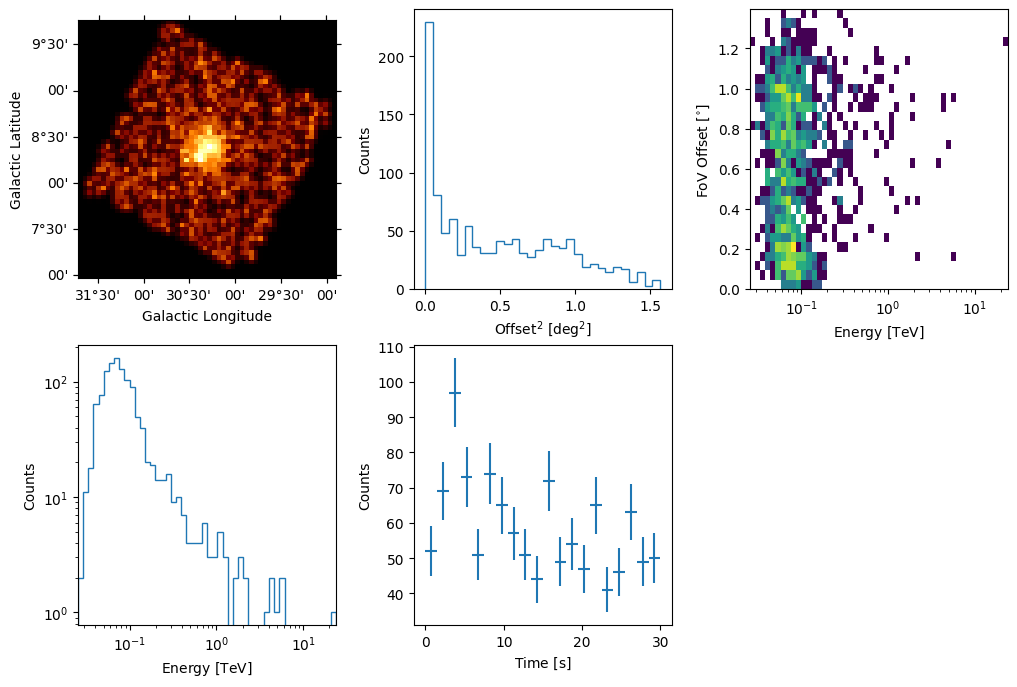

In [83]:
events.peek()

./.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1529 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


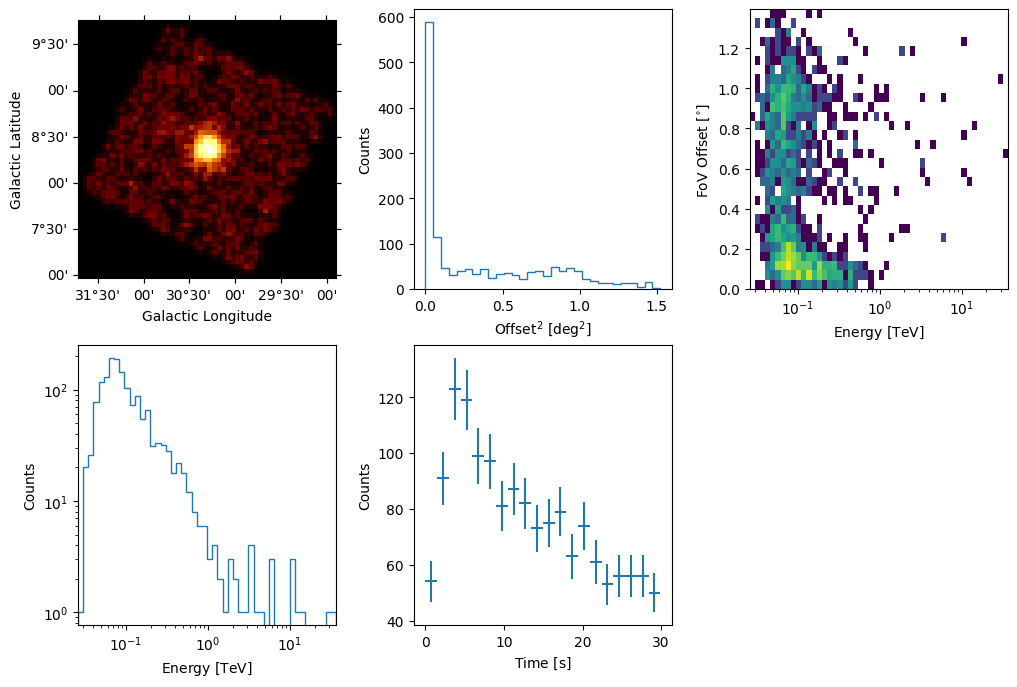

In [55]:
events.peek()